# Required Libraries + Load in Data

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [52]:
#read the csv file
dis19 = pd.read_csv("Train Disruptions 2019-2025/disruptions-2019.csv")

# Analyzing the Data

In [53]:
# Display basic information about the DataFrame: 
# number of rows, columns, data types, and non-null counts

dis19.info()

<class 'pandas.DataFrame'>
RangeIndex: 5940 entries, 0 to 5939
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rdt_id                5940 non-null   int64  
 1   ns_lines              5940 non-null   str    
 2   rdt_lines             5936 non-null   str    
 3   rdt_lines_id          5936 non-null   str    
 4   rdt_station_names     5939 non-null   str    
 5   rdt_station_codes     5939 non-null   str    
 6   cause_nl              5940 non-null   str    
 7   cause_en              5940 non-null   str    
 8   statistical_cause_nl  5940 non-null   str    
 9   statistical_cause_en  5940 non-null   str    
 10  cause_group           5940 non-null   str    
 11  start_time            5940 non-null   str    
 12  end_time              5937 non-null   str    
 13  duration_minutes      5937 non-null   float64
dtypes: float64(1), int64(1), str(12)
memory usage: 649.8 KB


In [54]:
# Display summary statistics for numerical columns
dis19.describe()

,rdt_id,duration_minutes
count,5940.000000,5937.000000
mean,28205.500000,96.943069
std,1714.874631,297.367167
min,25236.000000,0.000000
25%,26720.750000,12.000000
50%,28205.500000,40.000000
75%,29690.250000,113.000000
max,31175.000000,17011.000000


In [55]:
# Display summary for categorical columns
dis19.describe(include=["object", "string", "category"]) 

,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time
count,5940,5936,5936,5939,5939,5940,5940,5940,5940,5940,5940,5937
unique,411,273,273,948,948,70,67,70,67,9,5920,5937
top,Rotterdam-Breda (HSL),Breda - Rotterdam Centraal (HSL),15,"Breda,Rotterdam Centraal","BD, RTD",defecte trein,broken down train,defecte trein,broken down train,rolling stock,2019-01-08 17:56:08,2019-01-01 06:33:31
freq,307,293,293,293,293,2314,2314,2326,2326,2967,2,1


In [56]:
# Check if cause_en and statistical_cause_en columns are equal
dis19['cause_en'].equals(dis19['statistical_cause_en'])

False

In [57]:
# Check for values in 'cause_en' and 'statistical_cause_en' columns that are not the same
dis19.loc[dis19[['cause_en','statistical_cause_en']].nunique(1)>1]

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
90,25326,Utrecht-'s-Hertogenbosch,"'s-Hertogenbosch - Utrecht Centraal, Tiel - Ut...","150,151","Houten,Houten Castellum,Utrecht Centraal,Utrec...","HTN, HTNC, UT, UTLN, UTVR",eerdere verstoring,an earlier disruption,gestrande trein,stranded train,rolling stock,2019-01-07 17:57:09,2019-01-07 19:58:12,121.0
102,25338,Nijmegen-Venray,Nijmegen - Venlo,64,"Boxmeer,Cuijk,Mook-Molenhoek,Nijmegen,Nijmegen...","BMR, CK, MMLH, NM, NMH, VLB, VRY",eerdere verstoring,an earlier disruption,defecte trein,broken down train,rolling stock,2019-01-08 08:54:11,2019-01-08 12:51:10,237.0
121,25357,Amsterdam-Schiphol-Rotterdam (HSL),"Amsterdam Centraal - Schiphol Airport, Rotterd...","24,32","Amsterdam Centraal,Amsterdam Lelylaan,Amsterda...","ASD, ASDL, ASS, RTD, SHL",eerdere verstoring,an earlier disruption,verstoring elders,disruption elsewhere,logistical,2019-01-08 18:56:19,2019-01-09 02:11:02,435.0
284,25520,Nijmegen-Roermond,Nijmegen - Venlo,64,"Boxmeer,Cuijk,Mook-Molenhoek,Nijmegen,Nijmegen...","BMR, CK, MMLH, NM, NMH, VLB, VRY",eerdere verstoring,an earlier disruption,defecte trein,broken down train,rolling stock,2019-01-18 12:15:03,2019-01-18 15:02:05,167.0
468,25704,Schiphol Airport,"Amersfoort - Schiphol Airport, Amsterdam Centr...","22,24,32,137,144,148,165",Schiphol Airport,SHL,eerdere verstoring,an earlier disruption,inzet van de brandweer,deployment of the fire department,external,2019-01-25 18:06:18,2019-01-25 19:32:17,86.0
1040,26276,Arnhem-Duisburg-Düsseldorf,"Arnhem Centraal - Düsseldorf Hbf, Arnhem Centr...","129,178","Arnhem Centraal,Arnhem Velperpoort,Duiven,Emme...","AH, AHP, DVN, EM, ZV, WTV, EL",eerdere verstoring,an earlier disruption,verstoring elders,disruption elsewhere,logistical,2019-02-26 20:01:18,2019-02-26 22:53:28,172.0
1478,26714,Amsterdam-Schiphol-Rotterdam (HSL),"Amsterdam Centraal - Schiphol Airport, Rotterd...","24,32","Amsterdam Centraal,Amsterdam Lelylaan,Amsterda...","ASD, ASDL, ASS, RTD, SHL",eerdere verstoring,an earlier disruption,defecte trein,broken down train,rolling stock,2019-03-26 09:33:11,2019-03-26 14:01:15,268.0
1587,26823,Leiden-Alphen a/d Rijn,Leiden Centraal - Utrecht Centraal,147,"Alphen a/d Rijn,Leiden Lammenschans,Leiden Cen...","APN, LDL, LEDN",eerdere verstoring,an earlier disruption,overwegstoring,level crossing failure,infrastructure,2019-04-01 03:37:31,2019-04-01 09:54:18,377.0
1708,26944,Haarlem-Leiden,Haarlem - Leiden Centraal,23,"Hillegom,Leiden Centraal,Voorhout","HIL, LEDN, VH",eerdere verstoring,an earlier disruption,wisselstoring,points failure,infrastructure,2019-04-08 17:18:45,2019-04-08 19:27:01,128.0
1718,26954,Leiden-Den Haag C,Den Haag Centraal - Leiden Centraal,169,"De Vink,Den Haag Centraal,Den Haag Mariahoeve,...","DVNK, GVC, GVM, LAA, LEDN, VST",eerdere verstoring,an earlier disruption,wisselstoring,points failure,infrastructure,2019-04-08 17:44:12,2019-04-08 18:54:33,70.0


In [58]:
# Remove the following columns
dis19 = dis19.drop(['cause_nl', 'cause_en', 'statistical_cause_nl'], axis=1)

In [59]:
#Check if drop columns was successful 
dis19.columns.values

<StringArray>
[              'rdt_id',             'ns_lines',            'rdt_lines',
         'rdt_lines_id',    'rdt_station_names',    'rdt_station_codes',
 'statistical_cause_en',          'cause_group',           'start_time',
             'end_time',     'duration_minutes']
Length: 11, dtype: str

# Dealing with Missing Values

In [60]:
# Check for missing values in each column and calculate the percentage of missing values
total = dis19.isnull().sum().sort_values(ascending=False)
percent = (dis19.isnull().sum()/dis19.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
rdt_lines,4,0.000673
rdt_lines_id,4,0.000673
duration_minutes,3,0.000505
end_time,3,0.000505
rdt_station_names,1,0.000168
rdt_station_codes,1,0.000168
rdt_id,0,0.000000
ns_lines,0,0.000000
statistical_cause_en,0,0.000000
start_time,0,0.000000


In [61]:
# Display rows with missing values
null_data = dis19[dis19.isnull().any(axis=1)]
null_data

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
629,25865,Amsterdam-Brussel-Paris (HSL),NaN,NaN,NaN,NaN,disruption elsewhere,logistical,2019-02-03 22:06:26,2019-02-03 22:08:03,2.0
681,25917,Alkmaar-Hoorn,NaN,NaN,Hoorn,HN,broken down train,rolling stock,2019-02-06 16:41:05,2019-02-06 16:50:47,10.0
3080,28316,Hoofddorp-Schiphol-Almere Oostvaarders,NaN,NaN,Hoofddorp,HFD,broken down train,rolling stock,2019-07-04 19:58:18,2019-07-04 19:59:03,1.0
4072,29308,Zwolle-Groningen,Groningen - Zwolle,146,"Assen,Beilen,Hoogeveen,Meppel,Zwolle","ASN, BL, HGV, MP, ZL",broken down train,rolling stock,2019-09-04 20:24:37,NaN,NaN
4479,29715,Amsterdam-Köln-Frankfurt,Arnhem Centraal - Utrecht Centraal,133,"Arnhem Centraal,Bunnik,Driebergen-Zeist,Ede-Wa...","AH, BNK, DB, ED, KLP, MRN, OTB, UT, WF, UTVR",person hit by a train,accidents,2019-10-02 07:13:40,NaN,NaN
5492,30728,Arnhem-Duisburg-Düsseldorf,"Arnhem Centraal - Düsseldorf Hbf, Arnhem Centr...","129,178","Emmerich,Zevenaar","EM, ZV",broken down train,rolling stock,2019-12-04 14:32:20,NaN,NaN
5591,30827,Amsterdam-Haarlem,NaN,NaN,Haarlem Spaarnwoude,HLMS,broken down train,rolling stock,2019-12-10 14:53:25,2019-12-10 15:07:27,14.0


In [62]:
# Check for duplicates 
dis19.duplicated().sum()

np.int64(0)

In [63]:
# Make a list of numerical and categorical columns
num_cols = dis19.select_dtypes(include=np.number).columns  # rdt_id and duration_minutes
cat_cols = dis19.select_dtypes(exclude=np.number).columns

# Drop whole row if start_time or end_time is missing
# and duration_minutes is also missing
drop_rows = (
    (dis19["start_time"].isna() | dis19["end_time"].isna())
    & dis19["duration_minutes"].isna()
)
dis19 = dis19.loc[~drop_rows].copy()

# Fill specific categorical columns with 'Unknown'
cols_to_fill = ["rdt_lines", "rdt_lines_id", "rdt_station_names", "rdt_station_codes"]

for col in cols_to_fill:
    dis19[col] = dis19[col].fillna("Unknown")

# For all categorical columns: not controlable if too many categorical columns are missing
# for col in cat_cols:
#     dis19[col] = dis19[col].fillna("Unknown")

#Numerical columns: fill with median and create missing indicator
#Categorical columns: fill with 'Unknown'

# Make a list of numerical and categorical columns
# num_cols = dis19.select_dtypes(include=np.number).columns #rdt_id and duration_minutes
# cat_cols = dis19.select_dtypes(exclude=np.number).columns

# for col in num_cols:
#     if dis19[col].isna().any():
#         dis19[f"{col}_missing"] = dis19[col].isna().astype(int)
#         dis19[col] = dis19[col].fillna(dis19[col].median())

# for col in cat_cols:
#     dis19[col] = dis19[col].fillna("Unknown")

In [64]:
dis19.info()

<class 'pandas.DataFrame'>
Index: 5937 entries, 0 to 5939
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rdt_id                5937 non-null   int64  
 1   ns_lines              5937 non-null   str    
 2   rdt_lines             5937 non-null   str    
 3   rdt_lines_id          5937 non-null   str    
 4   rdt_station_names     5937 non-null   str    
 5   rdt_station_codes     5937 non-null   str    
 6   statistical_cause_en  5937 non-null   str    
 7   cause_group           5937 non-null   str    
 8   start_time            5937 non-null   str    
 9   end_time              5937 non-null   str    
 10  duration_minutes      5937 non-null   float64
dtypes: float64(1), int64(1), str(9)
memory usage: 556.6 KB


# Univariate & Bivariate Analysis

## Univariate

### Univariate: duration in minutes (duration_minutes)

duration_category
0–15 min      1758
16–30 min      783
31–60 min     1041
61–120 min     989
120+ min      1366
Name: count, dtype: int64

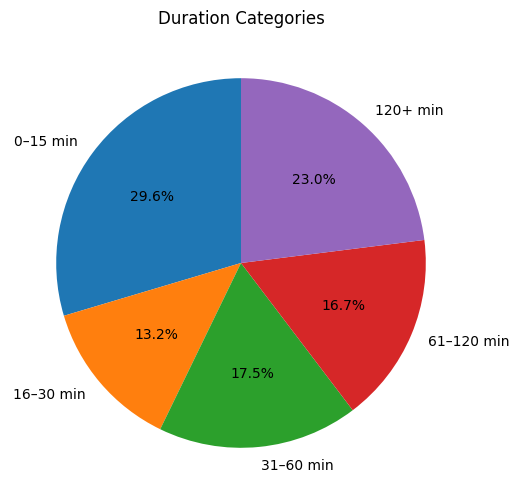

In [65]:
# General Univariate analysis for duration_minutes
duration = dis19["duration_minutes"].dropna()

# Categorize duration into groups
bins = [0, 15, 30, 60, 120, np.inf]
labels = ["0–15 min", "16–30 min", "31–60 min", "61–120 min", "120+ min"]

dis19["duration_category"] = pd.cut(
    dis19["duration_minutes"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Counts per category
duration_counts = dis19["duration_category"].value_counts().sort_index()
display(duration_counts)

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(duration_counts, labels=duration_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Duration Categories")
plt.show()

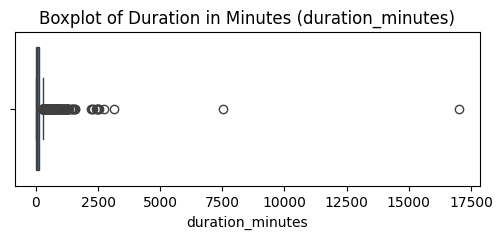

In [66]:
# Check the distribution of duration_minutes

plt.figure(figsize=(6, 2))
sns.boxplot(x=dis19['duration_minutes'])
plt.title("Boxplot of Duration in Minutes (duration_minutes)")
plt.show()

In [67]:
# Summary statistics
display(dis19['duration_minutes'].describe())

count     5937.000000
mean        96.943069
std        297.367167
min          0.000000
25%         12.000000
50%         40.000000
75%        113.000000
max      17011.000000
Name: duration_minutes, dtype: float64

In [68]:
# Identify outliers in duration_minutes using the Interquartile Range (IQR) method
# https://www.geeksforgeeks.org/pandas/handling-outliers-with-pandas/ 

Q1 = dis19['duration_minutes'].quantile(0.25) #12 minutes
Q3 = dis19['duration_minutes'].quantile(0.75) #113 minutes
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = dis19[(dis19['duration_minutes'] < lower_bound) | (dis19['duration_minutes'] > upper_bound)]
print("Outliers:\n")
outliers

#5937 rows, 11 columns, and 384 rows of outliers in duration_minutes column. 6.47% of the data are outliers.
# 1 day = 1440 minutes

Outliers:



,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,statistical_cause_en,cause_group,start_time,end_time,duration_minutes,duration_category
35,25271,Zwolle-Groningen,Groningen - Zwolle,146,"Hoogeveen,Meppel","HGV, MP",broken down train,rolling stock,2019-01-04 04:56:09,2019-01-05 22:47:07,2511.0,120+ min
40,25276,Hengelo-Bielefeld,"Berlin Ostbahnhof - Hengelo, Bielefeld Hbf - H...","124,174","Bad Bentheim,Oldenzaal","BH, ODZ",broken down train,rolling stock,2019-01-04 08:46:06,2019-01-04 13:20:51,275.0,120+ min
69,25305,Hengelo-Bielefeld,"Berlin Ostbahnhof - Hengelo, Bielefeld Hbf - H...","91,124,174","Bad Bentheim,Hengelo,Hengelo Oost,Oldenzaal","BH, HGL, HGLO, ODZ",problems with the rolling stock,rolling stock,2019-01-06 08:25:05,2019-01-06 21:49:09,804.0,120+ min
89,25325,Hoofddorp-Schiphol-Hilversum,"Amersfoort - Schiphol Airport, Leiden Centraal...","22,137,144,148","Amsterdam Zuid,Hoofddorp,Schiphol Airport","ASDZ, HFD, SHL",points failure,infrastructure,2019-01-07 14:20:47,2019-01-07 20:59:41,399.0,120+ min
97,25333,Alkmaar-Den Helder; Alkmaar-Hoorn,"Alkmaar - Den Helder, Alkmaar - Hoorn","162,163","Alkmaar,Alkmaar Noord,Heerhugowaard","AMR, AMRN, HWD",person hit by a train,accidents,2019-01-07 23:49:33,2019-01-08 07:18:42,449.0,120+ min
...,...,...,...,...,...,...,...,...,...,...,...,...
5781,31017,Amsterdam-Rotterdam-Brussel (HSL),"Amsterdam Centraal - Schiphol Airport, Rotterd...","24,32","Amsterdam Centraal,Amsterdam Lelylaan,Amsterda...","ASD, ASDL, ASS, RTD, SHL",stranded train,rolling stock,2019-12-20 13:38:41,2019-12-20 18:26:13,288.0,120+ min
5782,31018,Amsterdam-Brussel-Paris (HSL),Rotterdam Centraal - Schiphol Airport (HSL),24,"Rotterdam Centraal,Schiphol Airport","RTD, SHL",stranded train,rolling stock,2019-12-20 13:38:41,2019-12-20 18:26:24,288.0,120+ min
5838,31074,Utrecht-'s-Hertogenbosch,'s-Hertogenbosch - Utrecht Centraal,151,"Geldermalsen,'s-Hertogenbosch,Zaltbommel","GDM, HT, ZBM",collision,accidents,2019-12-23 17:54:03,2019-12-23 23:32:17,338.0,120+ min
5865,31101,Sittard-Heerlen-Kerkrade,Heerlen - Kerkrade Centrum,78,"Chevremont,Eygelshoven,Heerlen,Heerlen De Kiss...","CVM, EGH, HRL, HRLK, KRD, LG",signal and level crossing failure,infrastructure,2019-12-25 20:34:49,2019-12-26 01:03:25,269.0,120+ min


In [69]:
outliers.sort_values(by='duration_minutes', ascending=False).head(10)

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,statistical_cause_en,cause_group,start_time,end_time,duration_minutes,duration_category
2051,27287,Den Haag-Rotterdam-Breda (HSL); Den Haag-Rotte...,Dordrecht - Rotterdam Centraal,16,"Rotterdam Lombardijen,Rotterdam Blaak,Rotterda...","RLB, RTB, RTD, RTST, RTZ",person hit by a train,accidents,2019-04-26 16:53:44,2019-05-08 12:24:57,17011.0,120+ min
2897,28133,Sittard-Heerlen-Kerkrade,"Heerlen - Kerkrade Centrum, Heerlen - Sittard","77,78","Chevremont,Eygelshoven,Geleen Oost,Hoensbroek,...","CVM, EGH, GLN, HB, HRL, HRLK, KRD, LG, NH, SBK...",problems with the rolling stock,rolling stock,2019-06-25 18:34:52,2019-06-30 23:48:51,7514.0,120+ min
2958,28194,Zwolle-Almelo,Almelo - Zwolle,95,"Nijverdal,Raalte,Wierden","NVD, RAT, WDN",signal and level crossing failure,infrastructure,2019-06-28 19:12:10,2019-06-30 23:49:03,3157.0,120+ min
3622,28858,Hengelo-Oldenzaal,"Berlin Ostbahnhof - Hengelo, Bielefeld Hbf - H...","91,124,174","Hengelo,Hengelo Oost,Oldenzaal","HGL, HGLO, ODZ",problems with the rolling stock,rolling stock,2019-08-08 04:33:49,2019-08-10 02:06:52,2733.0,120+ min
585,25821,Hengelo-Bielefeld,"Berlin Ostbahnhof - Hengelo, Bielefeld Hbf - H...","91,124,174","Bad Bentheim,Hengelo,Hengelo Oost,Oldenzaal","BH, HGL, HGLO, ODZ",problems with the rolling stock,rolling stock,2019-02-01 01:50:34,2019-02-02 19:51:50,2521.0,120+ min
35,25271,Zwolle-Groningen,Groningen - Zwolle,146,"Hoogeveen,Meppel","HGV, MP",broken down train,rolling stock,2019-01-04 04:56:09,2019-01-05 22:47:07,2511.0,120+ min
3448,28684,Amsterdam-Schiphol-Rotterdam (HSL),"Amsterdam Centraal - Schiphol Airport, Rotterd...","24,32","Amsterdam Centraal,Amsterdam Lelylaan,Amsterda...","ASD, ASDL, ASS, RTD, SHL",problems with the rolling stock,rolling stock,2019-07-27 05:24:33,2019-07-28 22:54:02,2489.0,120+ min
3450,28686,Amsterdam-Haarlem-Den Haag,"Amsterdam Centraal - Haarlem, Amsterdam Centra...","22,23,32,112,169","Amsterdam Centraal,Amsterdam Lelylaan,Amsterda...","ASD, ASDL, ASS, DVNK, GVC, GVM, HAD, HFD, HIL,...",problems with the rolling stock,rolling stock,2019-07-27 06:38:41,2019-07-28 23:16:12,2438.0,120+ min
3988,29224,Hengelo-Bielefeld,"Berlin Ostbahnhof - Hengelo, Bielefeld Hbf - H...","91,124,174","Bad Bentheim,Hengelo,Hengelo Oost,Oldenzaal","BH, HGL, HGLO, ODZ",problems with the rolling stock,rolling stock,2019-08-31 08:22:58,2019-09-02 00:34:03,2411.0,120+ min
793,26029,Breda,"Antwerpen-Centraal - Breda (HSL), Breda - Dord...","15,20,68,170,177",Breda,BD,railway problems abroad,logistical,2019-02-12 15:22:55,2019-02-14 05:17:55,2275.0,120+ min


In [79]:
# Top 15 causes in outliers
outliers_top15 = outliers["statistical_cause_en"].value_counts().head(15)

# Count those same causes in full dataset (dis19)
dis19_for_outlier_top15 = (
    dis19["statistical_cause_en"]
    .value_counts()
    .reindex(outliers_top15.index, fill_value=0)
)

# Percentage of outliers relative to full dataset for the same cause
outlier_to_general_pct = (
    outliers_top15.div(dis19_for_outlier_top15.replace(0, np.nan)) * 100
).round(2)

# Show side by side
pd.DataFrame({
    "outliers_top15_count": outliers_top15,
    "dis19_count_for_same_causes": dis19_for_outlier_top15,
    "percentage": outlier_to_general_pct
})

,outliers_top15_count,dis19_count_for_same_causes,percentage
statistical_cause_en,,,
problems with the rolling stock,55,103,53.40
damaged overhead wires,48,136,35.29
signal failure,43,435,9.89
repair works,25,93,26.88
points failure,22,343,6.41
signal and level crossing failure,21,86,24.42
defective railway track,20,68,29.41
broken down train,18,2324,0.77
person hit by a train,17,319,5.33


In [ ]:
dis19[['statistical_cause_en']].value_counts()

statistical_cause_en             
broken down train                    2324
stranded train                        535
signal failure                        435
points failure                        343
person hit by a train                 319
an emergency call                     181
disruption elsewhere                  141
collision                             138
damaged overhead wires                136
damaged railway bridge                126
person on the railway track           108
problems with the rolling stock       103
repair works                           93
level crossing failure                 90
signal and level crossing failure      86
Name: count, dtype: int64

In [81]:
dis19[dis19['statistical_cause_en'] == 'weather circumstances']

,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,statistical_cause_en,cause_group,start_time,end_time,duration_minutes,duration_category
581,25817,Amersfoort-Deventer,"Amersfoort - Apeldoorn, Apeldoorn - Deventer","50,87","Amersfoort Centraal,Apeldoorn,Apeldoorn Osseve...","AMF, APD, APDO, DV, TWL",weather circumstances,weather,2019-02-01 02:22:28,2019-02-01 09:56:46,454.0,120+ min
582,25818,Ede-Wageningen-Arnhem,Arnhem Centraal - Utrecht Centraal,133,"Arnhem Centraal,Ede-Wageningen,Oosterbeek,Wolf...","AH, ED, OTB, WF",weather circumstances,weather,2019-02-01 02:23:44,2019-02-01 09:56:08,452.0,120+ min
583,25819,Arnhem-Nijmegen; Nijmegen-Wijchen,"'s-Hertogenbosch - Nijmegen, Arnhem Centraal -...","57,59","Arnhem Centraal,Arnhem Zuid,Elst,Nijmegen,Nijm...","AH, AHZ, EST, NM, NMD, NML, WC, NMGO",weather circumstances,weather,2019-02-01 02:25:14,2019-02-01 09:55:47,451.0,120+ min
584,25820,Amsterdam-Utrecht; Eindhoven-Heerlen; Utrecht-...,"'s-Hertogenbosch - Eindhoven, 's-Hertogenbosch...","67,73,136,151,153","Abcoude,Amsterdam Amstel,Amsterdam Bijlmer Are...","AC, ASA, ASB, ASD, ASDM, ASHD, BET, BKL, BTL, ...",weather circumstances,weather,2019-02-01 02:29:37,2019-02-01 09:56:29,447.0,120+ min
591,25827,Utrecht-Houten,"'s-Hertogenbosch - Utrecht Centraal, Tiel - Ut...","150,151","Houten,Houten Castellum,Utrecht Centraal,Utrec...","HTN, HTNC, UT, UTLN, UTVR",weather circumstances,weather,2019-02-01 07:24:38,2019-02-01 08:57:49,93.0,61–120 min
1204,26440,Sittard-Heerlen-Kerkrade,"Heerlen - Kerkrade Centrum, Heerlen - Sittard","77,78","Chevremont,Eygelshoven,Geleen Oost,Hoensbroek,...","CVM, EGH, GLN, HB, HRL, HRLK, KRD, LG, NH, SBK...",weather circumstances,weather,2019-03-10 15:40:29,2019-03-10 22:26:20,406.0,120+ min
1210,26446,Heerlen-Maastricht,Heerlen - Maastricht,76,"Heerlen,Heerlen Woonboulevard,Klimmen-Ransdaal...","HRL, HRLW, KMR, MES, MT, SGL, SOG, VDL, VK, MTN",weather circumstances,weather,2019-03-10 19:01:31,2019-03-10 22:14:23,193.0,120+ min
1211,26447,Sittard-Maastricht,Maastricht - Sittard,74,"Bunde,Beek-Elsloo,Geleen-Lutterade,Maastricht,...","BDE, BK, LUT, MT, STD",weather circumstances,weather,2019-03-10 19:20:35,2019-03-10 22:56:46,216.0,120+ min
1213,26449,Heerlen-Herzogenrath,Aachen Hbf - Heerlen,130,"Eygelshoven Markt,Heerlen,Heerlen De Kissel,He...","EGHM, HRL, HRLK, HZ, LG",weather circumstances,weather,2019-03-10 21:43:40,2019-03-11 00:01:01,137.0,120+ min
1214,26450,Sittard-Heerlen-Kerkrade,"Heerlen - Kerkrade Centrum, Heerlen - Sittard","77,78","Chevremont,Eygelshoven,Geleen Oost,Hoensbroek,...","CVM, EGH, GLN, HB, HRL, HRLK, KRD, LG, NH, SBK...",weather circumstances,weather,2019-03-10 22:51:25,2019-03-11 00:28:26,97.0,61–120 min


duration_category
241–480 min     225
481–720 min      79
721–1440 min     62
1440+ min        18
Name: count, dtype: int64

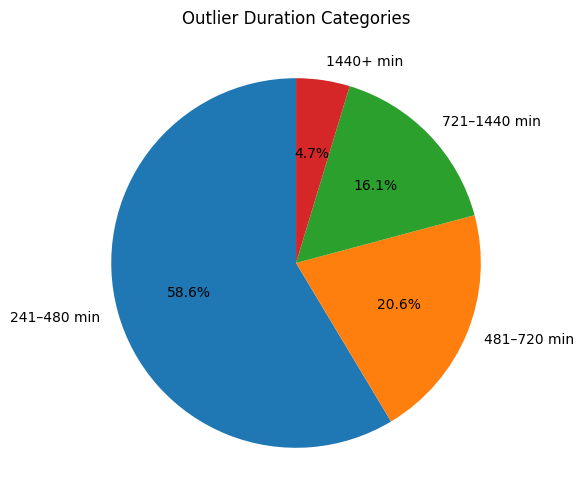

In [71]:
# Univariate analysis for outliers duration_minutes

duration = outliers["duration_minutes"].dropna()

# Categorize outliers into groups (all outliers are above upper_bound ~264 min)
bins = [240, 480, 720, 1440, np.inf] #bins 0-240 was removed because all outliers are above 240 minutes
labels = ["241–480 min", "481–720 min", "721–1440 min", "1440+ min"]

outliers = outliers.copy()
outliers["duration_category"] = pd.cut(
    outliers["duration_minutes"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Counts per category
duration_counts = outliers["duration_category"].value_counts().sort_index()
display(duration_counts)

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(duration_counts, labels=duration_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Outlier Duration Categories")
plt.show()

### Univariate: Categorical (TO DO)

In [ ]:
# Plot all categorical columns, 3 charts per row
n_cols = 3
n_plots = len(cat_cols)
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cat_cols):
    counts = dis19[col].astype(str).value_counts()
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"{col} - All categories")
    axes[i].tick_params(axis="x", rotation=60)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Hide any unused subplot slots
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

C:\Users\johan\AppData\Local\Temp\ipykernel_8020\3609215035.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x=counts.index, y=counts.values, palette="viridis")
C:\Users\johan\AppData\Local\Temp\ipykernel_8020\3609215035.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x=counts.index, y=counts.values, palette="viridis")
C:\Users\johan\AppData\Local\Temp\ipykernel_8020\3609215035.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x=counts.index, y=counts.values, palette="viridis")
C:\Users\johan\A

KeyboardInterrupt: 

## Bivariate

### Bivariate: Categorical

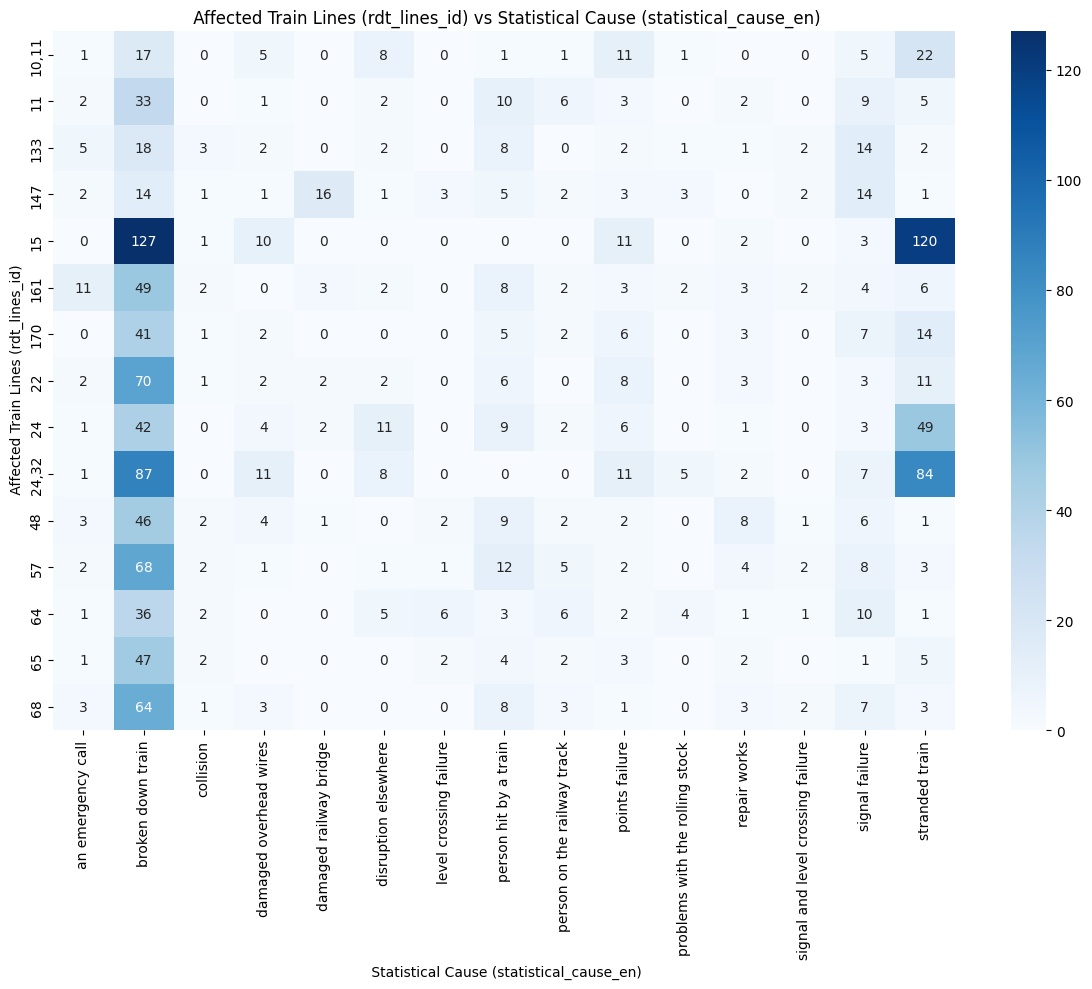

In [73]:
# Compare two columns with a simple heatmap
col1 = "rdt_lines_id"            # Affected train lines
col2 = "statistical_cause_en"    # Statistical cause

tmp = dis19[[col1, col2]].dropna().astype(str)

# Keep only top 15 categories so the plot stays readable
top_n = 15
top_col1 = tmp[col1].value_counts().head(top_n).index
top_col2 = tmp[col2].value_counts().head(top_n).index
tmp = tmp[tmp[col1].isin(top_col1) & tmp[col2].isin(top_col2)]

heatmap_data = pd.crosstab(tmp[col1], tmp[col2])

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues")
plt.title(f" Affected Train Lines ({col1}) vs Statistical Cause ({col2})")
plt.xlabel(f" Statistical Cause ({col2})")
plt.ylabel(f" Affected Train Lines ({col1})")
plt.tight_layout()
plt.show()

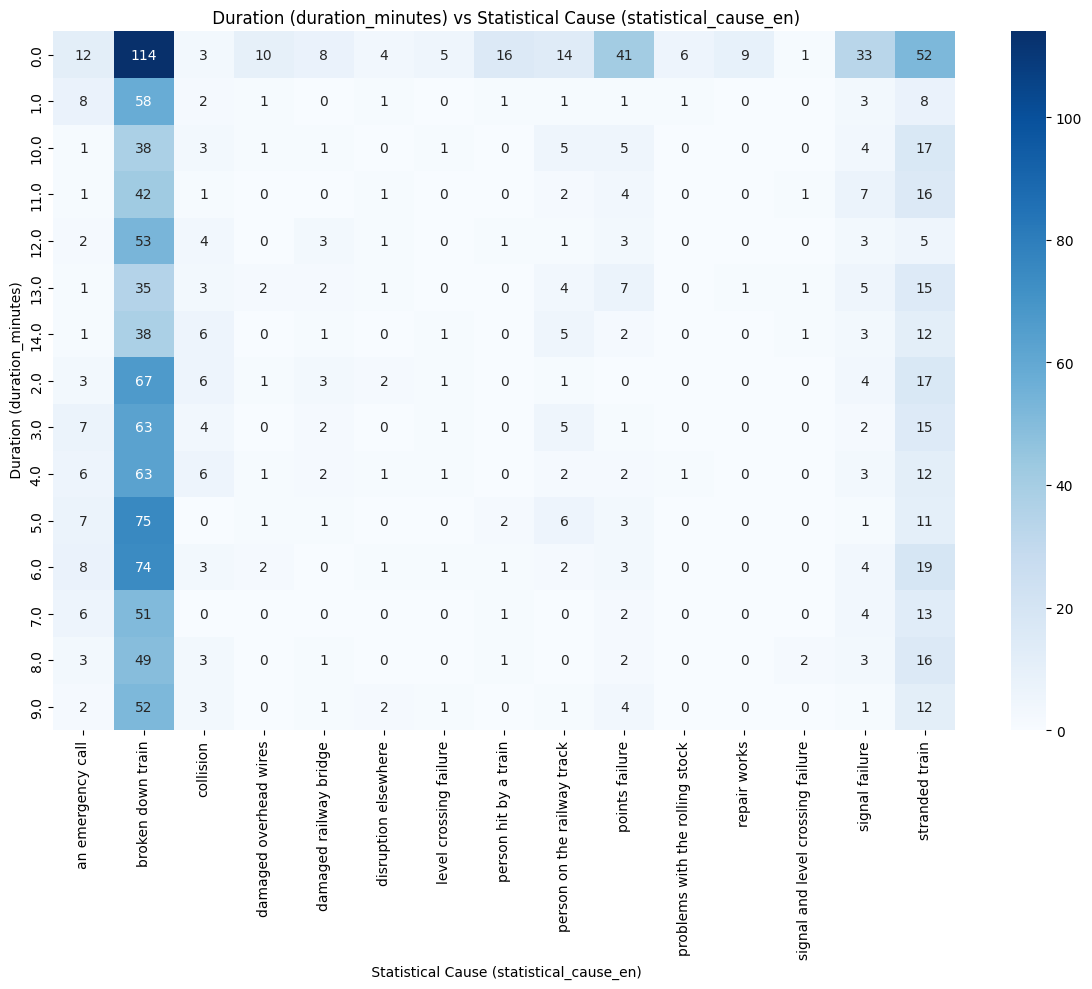

In [74]:
# Compare two columns with a simple heatmap
col1 = "duration_minutes"       # Duration in minutes
col2 = "statistical_cause_en"   # Statistical cause

tmp = dis19[[col1, col2]].dropna().astype(str)

# Keep only top 15 categories so the plot stays readable
top_n = 15
top_col1 = tmp[col1].value_counts().head(top_n).index
top_col2 = tmp[col2].value_counts().head(top_n).index
tmp = tmp[tmp[col1].isin(top_col1) & tmp[col2].isin(top_col2)]

heatmap_data = pd.crosstab(tmp[col1], tmp[col2])

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues")
plt.title(f" Duration ({col1}) vs Statistical Cause ({col2})")
plt.xlabel(f" Statistical Cause ({col2})")
plt.ylabel(f" Duration ({col1})")
plt.tight_layout()
plt.show()